# Validating the merged-clock EMA against own-clock EMAs

A direct test of the `docs/ema_event_clock.md` design. Claim: a per-exchange flow
EMA computed on the **merged trade clock** at a large window N reproduces the same
exchange's EMA computed on its **own** trade clock at the window `N_ex` that spans
the same average wall-clock time — *despite* the per-exchange decay varying tick
to tick on the merged clock. We then watch the agreement loosen as N shrinks.

**Procedure**
1. Build the merged eth_usdt_p trade stream (bin+byb+okx, ordered by `rx_time`).
   For a large `N` (=20000), measure the mean wall-clock duration `D` of an
   N-trade merged window.
2. For each exchange, tune `N_ex` on its *own* trade stream so its mean N_ex-trade
   window duration ≈ `D`.
3. Compute the exchange's **trade-volume EMA** two ways and compare:
   - **merged clock, N**: the design's debiased average `E/W` (§4) — `E` and `W`
     are constant-decay filters on the merged stream, so this is just
     `lfilter(E)/lfilter(W)` sampled at the exchange's trades.
   - **own clock, N_ex**: a plain constant-α EMA on the exchange's own trades.
4. Repeat for small N (1000, 100) to see where the approximation frays.

`E/W` is the apples-to-apples match to a per-trade own-clock EMA (both are
"average trade volume"); the raw intensity `E` would carry the rate factor.

In [1]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from scipy.signal import lfilter
from boba.io import load_block, list_blocks

COIN = "eth_usdt_p"
EX = ["bin", "byb", "okx"]
NS = [20000, 1000, 100, 50, 25, 10]
SCATTER_NS = [20000, 100, 10]                # representative subset for the scatter panels
BLOCK = list_blocks(f"bin_{COIN}", "trade")[0]
print("block:", BLOCK)

block: holocron.20260520T135822.0


## Build the merged trade stream

In [2]:
def load_ex(ex):
    td = (load_block(BLOCK, f"{ex}_{COIN}", "trade").select("rx_time", "prc", "qty")
          .filter((pl.col("prc") > 0) & (pl.col("qty") > 0)).sort("rx_time"))   # drop bin zero-prints
    return td["rx_time"].cast(pl.Int64).to_numpy(), td["qty"].to_numpy()

rxs, qtys, eids = [], [], []
for k, ex in enumerate(EX):
    rx, qty = load_ex(ex)
    rxs.append(rx); qtys.append(qty); eids.append(np.full(len(rx), k))
mrx = np.concatenate(rxs); mqty = np.concatenate(qtys); meid = np.concatenate(eids)
o = np.argsort(mrx, kind="stable")
mrx, mqty, meid = mrx[o], mqty[o], meid[o]               # merged stream, rx-ordered
M = len(mrx)
pos = {k: np.flatnonzero(meid == k) for k in range(len(EX))}   # each ex's merged indices

pl.DataFrame({"exchange": EX,
              "trades": [len(pos[k]) for k in range(len(EX))],
              "share": [round(len(pos[k]) / M, 3) for k in range(len(EX))]})

exchange,trades,share
str,i64,f64
"""bin""",3689867,0.595
"""byb""",1618754,0.261
"""okx""",889567,0.144


## Helpers — window duration, own-clock EMA, merged-clock E/W

In [3]:
def mean_window_dur(rx, N):
    return float(np.mean(rx[N:] - rx[:-N]) / 1e9)         # seconds

def ema_own(x, N):                                        # constant-alpha EMA, debiased
    a = 2.0 / (N + 1.0)
    y = lfilter([a], [1.0, -(1.0 - a)], x.astype(np.float64))
    return y / (1.0 - (1.0 - a) ** np.arange(1, len(x) + 1))

def ema_merged(k, N):                                     # design's E/W on the merged clock
    lam = 1.0 - 2.0 / (N + 1.0)
    E = lfilter([1.0], [1.0, -lam], np.where(meid == k, mqty, 0.0))
    W = lfilter([1.0], [1.0, -lam], (meid == k).astype(np.float64))
    return E[pos[k]] / W[pos[k]]                          # sampled at this ex's trades

## Oracle check — `lfilter` `E/W` vs a dead-simple arrival-order loop

Per the project rule, the vectorised path is validated against an independent,
trivially-simple reference: stream **every merged trade in arrival order**, keep a
per-exchange `(E, W)` flow EMA on the merged clock (decay all exchanges one tick,
inject for the one that traded), and read `E/W` at each event's own exchange. No
`lfilter`, no vectorisation. It must match the filtered version on the real block.

In [4]:
def ema_merged_loop(N):
    lam = 1.0 - 2.0 / (N + 1.0)
    nx = len(EX)
    E = [0.0] * nx; W = [0.0] * nx; out = [[] for _ in range(nx)]
    eid = meid.tolist(); q = mqty.tolist()                # lists -> faster scalar access
    for m in range(M):
        for j in range(nx):                               # decay every exchange one merged tick
            E[j] *= lam; W[j] *= lam
        k = eid[m]                                        # inject for the exchange that traded
        E[k] += q[m]; W[k] += 1.0
        out[k].append(E[k] / W[k])                        # record its E/W at this trade
    return [np.asarray(c) for c in out]

for N in (20000, 100):
    loop = ema_merged_loop(N)
    for k, ex in enumerate(EX):
        assert np.allclose(loop[k], ema_merged(k, N), rtol=1e-9, atol=1e-9), (ex, N)
    print(f"N={N:>6}: lfilter E/W == arrival-order loop on all {M:,} events, every exchange  OK")

N= 20000: lfilter E/W == arrival-order loop on all 6,198,188 events, every exchange  OK


N=   100: lfilter E/W == arrival-order loop on all 6,198,188 events, every exchange  OK


## Steps 1–3 — tune N_ex to match D, then compare the two EMAs

In [5]:
rows, scatter, overlay = [], {}, {}
for N in NS:
    D = mean_window_dur(mrx, N)
    for k, ex in enumerate(EX):
        ex_rx = mrx[pos[k]]
        rate = (len(ex_rx) - 1) / ((ex_rx[-1] - ex_rx[0]) / 1e9)
        N_ex = max(2, round(D * rate))                    # tune to the merged window duration
        vm = ema_merged(k, N)
        vo = ema_own(mqty[pos[k]], N_ex)
        skip = min(5 * N_ex, len(vm) // 2)                # drop warmup
        a, b = vm[skip:], vo[skip:]
        rows.append(dict(N=N, D_s=round(D, 3), exchange=ex, N_ex=N_ex,
                         dur_ex_s=round(mean_window_dur(ex_rx, N_ex), 3),
                         med_rel_pct=round(float(np.median(np.abs(a - b) / b)) * 100, 2),
                         corr=round(float(np.corrcoef(a, b)[0, 1]), 3)))
        sub = np.linspace(0, len(a) - 1, min(4000, len(a))).astype(int)
        scatter[(N, ex)] = (a[sub], b[sub])
        if N == 20000 and ex == "okx":
            overlay[N] = (ex_rx[skip:], vm[skip:], vo[skip:])

res = pl.DataFrame(rows)
pl.Config.set_tbl_rows(20); pl.Config.set_tbl_cols(20)
res

N,D_s,exchange,N_ex,dur_ex_s,med_rel_pct,corr
i64,f64,str,i64,f64,f64,f64
20000,279.137,"""bin""",11922,279.482,0.31,1.0
20000,279.137,"""byb""",5230,279.556,0.95,0.999
20000,279.137,"""okx""",2874,279.43,1.08,0.991
1000,13.939,"""bin""",595,13.932,2.36,0.99
1000,13.939,"""byb""",261,13.93,5.71,0.964
1000,13.939,"""okx""",144,13.985,6.59,0.937
100,1.394,"""bin""",60,1.405,12.23,0.957
100,1.394,"""byb""",26,1.388,25.44,0.817
100,1.394,"""okx""",14,1.36,27.68,0.773


### Agreement at N = 20000 — the merged-clock EMA reproduces the own-clock EMA

Left: okx (the minority venue, the hardest case) — merged `E/W` vs the wall-clock
matched own-clock EMA over a slice; the two curves sit on top of each other.
Right: merged vs own for all three venues — tight on the diagonal.

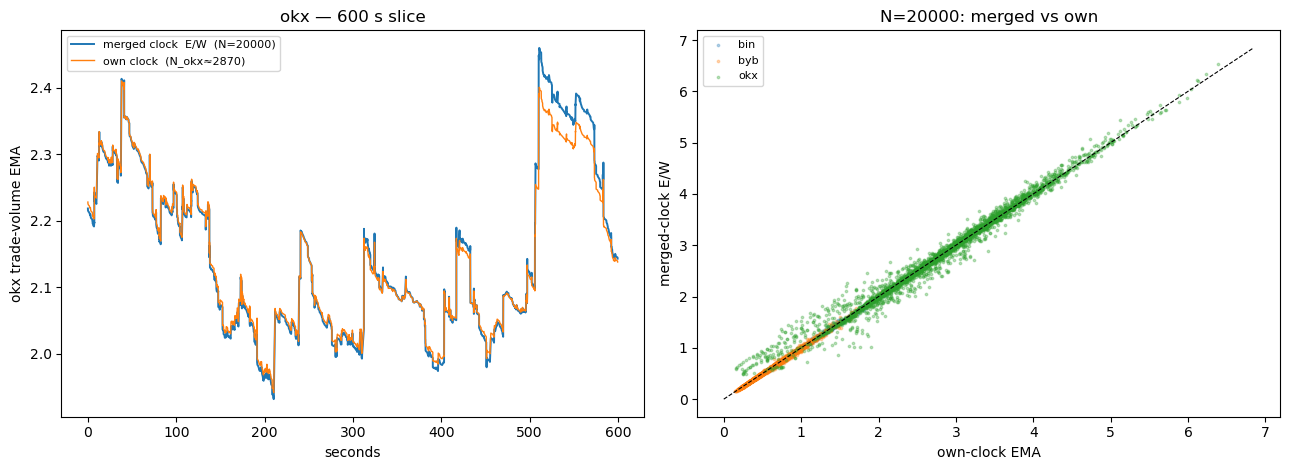

In [6]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4.8))
t, vm, vo = overlay[20000]
t0 = t[0] + (t[-1] - t[0]) // 2
w = (t >= t0) & (t < t0 + 600_000_000_000)               # 600 s slice
ts = (t[w] - t[w][0]) / 1e9
axL.plot(ts, vm[w], lw=1.4, label="merged clock  E/W  (N=20000)")
axL.plot(ts, vo[w], lw=1.0, label="own clock  (N_okx≈2870)")
axL.set_xlabel("seconds"); axL.set_ylabel("okx trade-volume EMA"); axL.set_title("okx — 600 s slice")
axL.legend(fontsize=8)
for ex, c in zip(EX, ["C0", "C1", "C2"]):
    a, b = scatter[(20000, ex)]
    axR.scatter(b, a, s=3, alpha=0.3, color=c, label=ex)
lim = [0, max(axR.get_xlim()[1], axR.get_ylim()[1])]
axR.plot(lim, lim, "k--", lw=0.8)
axR.set_xlabel("own-clock EMA"); axR.set_ylabel("merged-clock E/W"); axR.set_title("N=20000: merged vs own")
axR.legend(fontsize=8); fig.tight_layout()

## Small N — where does the approximation fray?

The agreement loosens as N shrinks (down to N=10 here), and always more for the
minority venue (fewer of its own trades land in the window). This is the small-N
under-sampling the design flags — inherent to "the last N merged trades", not a
defect of the EMA. The next section shows this is also where the cross-exchange
signal lives.

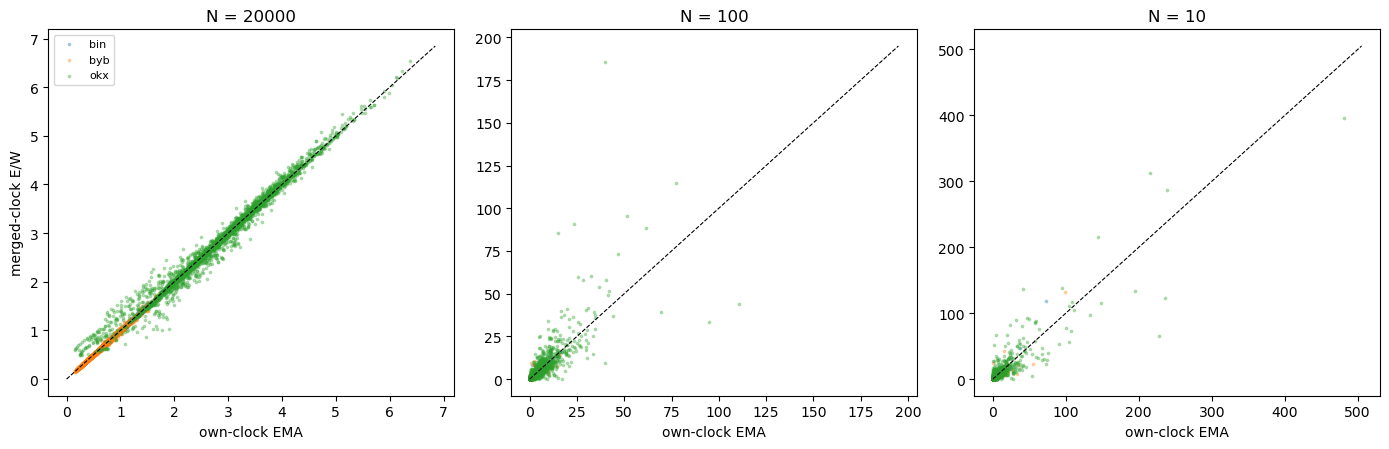

In [7]:
fig, axes = plt.subplots(1, len(SCATTER_NS), figsize=(14, 4.6))
for ax, N in zip(axes, SCATTER_NS):
    for ex, c in zip(EX, ["C0", "C1", "C2"]):
        a, b = scatter[(N, ex)]
        ax.scatter(b, a, s=3, alpha=0.3, color=c, label=ex)
    lim = [0, max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot(lim, lim, "k--", lw=0.8)
    ax.set_title(f"N = {N}"); ax.set_xlabel("own-clock EMA")
axes[0].set_ylabel("merged-clock E/W"); axes[0].legend(fontsize=8)
fig.tight_layout()

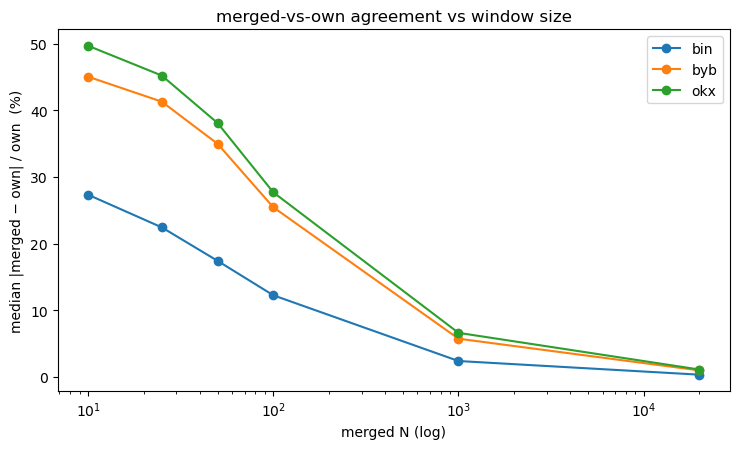

In [8]:
# agreement (median |rel diff|) vs N, per exchange
fig, ax = plt.subplots(figsize=(7.5, 4.6))
for ex, c in zip(EX, ["C0", "C1", "C2"]):
    d = res.filter(pl.col("exchange") == ex).sort("N")
    ax.plot(d["N"], d["med_rel_pct"], "o-", color=c, label=ex)
ax.set_xscale("log"); ax.set_xlabel("merged N (log)"); ax.set_ylabel("median |merged − own| / own  (%)")
ax.set_title("merged-vs-own agreement vs window size"); ax.legend(); fig.tight_layout()

## Where the signal lives — cross-exchange lead/lag

If the small-N "breakdown" is where the alpha is, the cross-exchange lead/lag should
sit at the same wall-clock scale. Build each venue's mid on a common 25 ms grid,
take log-returns, and cross-correlate `C(lag) = corr(r_lead[t], r_follow[t+lag])`.
A positive-lag peak means `follow` trails `lead`. *(Loads front_levels — heavier.)*

grid: 3,455,622 cells @ 25ms


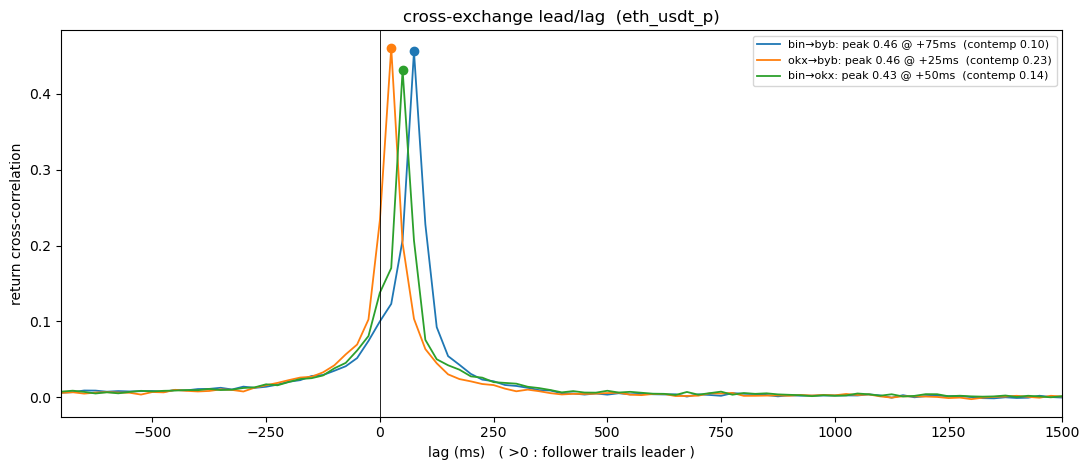

In [9]:
import gc
DT = 25 * 1_000_000          # 25 ms grid
K = 80                       # +/- 2 s of lag

def load_mid(ex):
    fl = (load_block(BLOCK, f"{ex}_{COIN}", "front_levels").select("rx_time", "bid_prc", "ask_prc")
          .drop_nulls().sort("rx_time"))
    rx = fl["rx_time"].cast(pl.Int64).to_numpy()
    return rx, (fl["bid_prc"].to_numpy() + fl["ask_prc"].to_numpy()) / 2.0

raw = {ex: load_mid(ex) for ex in EX}
grid = np.arange(max(rx[0] for rx, _ in raw.values()), min(rx[-1] for rx, _ in raw.values()), DT)
rgrid = {ex: np.diff(np.log(mid[np.searchsorted(rx, grid, "right") - 1])) for ex, (rx, mid) in raw.items()}
del raw; gc.collect()
print(f"grid: {len(grid):,} cells @ {DT//1_000_000}ms")

def xcorr(a, b, K):
    za = (a - a.mean()) / a.std(); zb = (b - b.mean()) / b.std(); n = len(a)
    return np.array([np.mean(za[:n - l] * zb[l:]) if l >= 0 else np.mean(za[-l:] * zb[:n + l])
                     for l in range(-K, K + 1)])

lags = np.arange(-K, K + 1) * DT / 1e9          # seconds
PAIRS = [("bin", "byb", "C0"), ("okx", "byb", "C1"), ("bin", "okx", "C2")]
xc = {}
fig, ax = plt.subplots(figsize=(11, 4.8))
for lead, follow, c in PAIRS:
    cc = xcorr(rgrid[lead], rgrid[follow], K); xc[(lead, follow)] = cc
    pk = int(np.nanargmax(cc))
    ax.plot(lags * 1000, cc, color=c, lw=1.3,
            label=f"{lead}→{follow}: peak {cc[pk]:.2f} @ {lags[pk]*1000:+.0f}ms  (contemp {cc[K]:.2f})")
    ax.plot(lags[pk] * 1000, cc[pk], "o", color=c)
ax.axvline(0, color="k", lw=0.6); ax.set_xlim(-700, 1500)
ax.set_xlabel("lag (ms)   ( >0 : follower trails leader )"); ax.set_ylabel("return cross-correlation")
ax.set_title(f"cross-exchange lead/lag  ({COIN})"); ax.legend(fontsize=8); fig.tight_layout()

### The punchline — the EMA frays exactly where the lead/lag lives

Both phenomena on one wall-clock axis: the merged-vs-own EMA disagreement against the
window *duration* `D_N`, and the bin→byb predictive correlation against horizon. The
disagreement climbs into the same sub-second-to-seconds band where the signal
concentrates — so the small-N "error" is the cross-exchange structure becoming
visible, not noise to be removed.

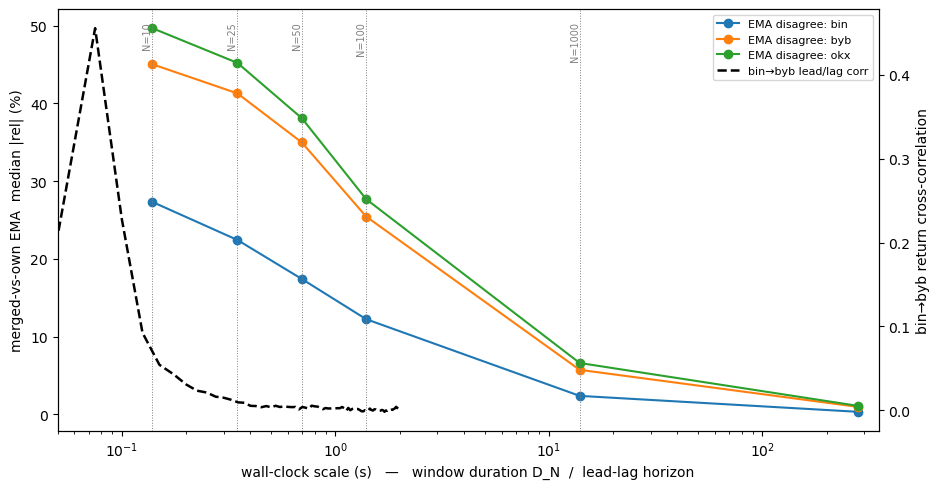

In [10]:
fig, ax1 = plt.subplots(figsize=(9.5, 5))
for ex, c in zip(EX, ["C0", "C1", "C2"]):
    d = res.filter(pl.col("exchange") == ex).sort("D_s")
    ax1.plot(d["D_s"], d["med_rel_pct"], "o-", color=c, label=f"EMA disagree: {ex}")
ax1.set_xscale("log"); ax1.set_xlabel("wall-clock scale (s)   —   window duration D_N  /  lead-lag horizon")
ax1.set_ylabel("merged-vs-own EMA  median |rel| (%)")
for N in [10, 25, 50, 100, 1000]:
    Dn = float(res.filter(pl.col("N") == N)["D_s"][0])
    ax1.axvline(Dn, color="grey", ls=":", lw=0.7)
    ax1.text(Dn, ax1.get_ylim()[1] * 0.97, f"N={N}", rotation=90, fontsize=7, va="top", ha="right", color="grey")
ax2 = ax1.twinx()
cc = xc[("bin", "byb")]; pos = lags > 0
ax2.plot(lags[pos], cc[pos], "k--", lw=1.8, label="bin→byb lead/lag corr")
ax2.set_ylabel("bin→byb return cross-correlation")
h1, l1 = ax1.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, fontsize=8, loc="upper right")
ax1.set_xlim(0.05, 350); fig.tight_layout()

## Read-out

**Validated at large N.** At N=20000 (≈280 s) merged-clock `E/W` and the wall-clock
matched own-clock EMA agree to **0.3–1.1%** (corr ≈ 1): the merged clock faithfully
reproduces a per-exchange EMA when the window is long enough to average the venues
into lockstep. (And `Σ N_ex ≈ N` — superposition: the merged rate is the sum of the
venue rates.)

**Frays at small N — and that's where the signal is.** Disagreement grows
monotonically as N shrinks (2–7% @1000, 12–28% @100, more by N=10) and with falling
venue share. The lead/lag says why: **bin leads byb by ~75 ms and okx by ~50 ms**
(okx→byb ~25 ms), peaking at 25–75 ms with a tail to ~1 s — the contemporaneous
bin→byb correlation is just 0.10 vs a lagged peak of 0.46, so byb genuinely *trails*
bin. That ~0.03–1 s band is exactly the N≈10–100 window-duration range where the EMA
approximation breaks down (punchline plot).

**Design consequence.** The small-N merged clock is not a regime to clean up — it is
the substrate the lead/lag alpha needs. Putting minority venues on their own clocks
(deferred option 2) would decouple them and *erase* this cross-venue timing. Keep the
single merged clock, expose all scales {10…20000}, and read the lead/lag from the
small-N **rates / intensities and cross-venue ratios** — not `E/W`, which (as the
agreement shows) converges to the own-clock average and so discards the timing.
Large-N features are clean aggregates; small-N features carry the prediction.